# 07 — Comparación de las series con catch22


## 1. Preparación y reproducibilidad

El notebook reutiliza `cargar_serie` del proyecto y las funciones verificadas de
`src/catch22_analysis.py`. Todos los resultados tabulares se guardan en
`data/processed/resultados/` y las figuras en `informe/img/laboratorio2/`.

In [1]:
from itertools import combinations
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RAIZ = Path.cwd().resolve()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

from catch22_analysis import (
    calcular_clustering,
    calcular_pca,
    construir_matriz_catch22,
    estandarizar_matriz,
    graficar_heatmap,
    matriz_correlacion,
    matriz_distancias,
)
from utils_ts import cargar_serie

DIR_RESULTADOS = RAIZ / "data" / "processed" / "resultados"
DIR_IMG = RAIZ / "informe" / "img" / "laboratorio2"
DIR_RESULTADOS.mkdir(parents=True, exist_ok=True)
DIR_IMG.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid")

## 2. Series incluidas

Se utiliza la serie total S0, las tres fronteras S1–S3 y los tres países S4–S6.
`S0_total_todos_tipos` no se incluye porque en el Laboratorio 1 se conservó
únicamente como contexto para explicar el cambio metodológico de 2023, no forma
parte de las siete series analíticas oficiales.

In [2]:
METADATOS_SERIES = {
    "S0_total": ("Total mensual", "Total"),
    "S1_la_aurora": ("La Aurora", "Frontera"),
    "S2_valle_nuevo": ("Valle Nuevo", "Frontera"),
    "S3_san_cristobal": ("San Cristóbal", "Frontera"),
    "S4_el_salvador": ("El Salvador", "País"),
    "S5_estados_unidos": ("Estados Unidos", "País"),
    "S6_guatemala": ("Guatemala", "País"),
}

series = {nombre: cargar_serie(nombre) for nombre in METADATOS_SERIES}
resumen_series = pd.DataFrame([
    {
        "serie": nombre,
        "nombre": METADATOS_SERIES[nombre][0],
        "categoria": METADATOS_SERIES[nombre][1],
        "observaciones": len(serie),
        "inicio": serie.index.min().date(),
        "fin": serie.index.max().date(),
        "faltantes": int(serie.isna().sum()),
        "ceros": int(serie.eq(0).sum()),
    }
    for nombre, serie in series.items()
]).set_index("serie")

assert len(series) == 7
assert resumen_series["observaciones"].eq(210).all()
assert resumen_series["faltantes"].eq(0).all()
resumen_series

,nombre,categoria,observaciones,inicio,fin,faltantes,ceros
serie,,,,,,,
S0_total,Total mensual,Total,210,2009-01-01,2026-06-01,0,0
S1_la_aurora,La Aurora,Frontera,210,2009-01-01,2026-06-01,0,0
S2_valle_nuevo,Valle Nuevo,Frontera,210,2009-01-01,2026-06-01,0,0
S3_san_cristobal,San Cristóbal,Frontera,210,2009-01-01,2026-06-01,0,0
S4_el_salvador,El Salvador,País,210,2009-01-01,2026-06-01,0,5
S5_estados_unidos,Estados Unidos,País,210,2009-01-01,2026-06-01,0,5
S6_guatemala,Guatemala,País,210,2009-01-01,2026-06-01,0,42


## 3. Idea detrás de catch22 (2.1)

**catch22** significa *22 CAnonical Time-series CHaracteristics*. Resume cada
serie mediante un vector compacto de propiedades estadísticas relacionadas con
la forma de la distribución, autocorrelación lineal y no lineal, periodicidad,
cambios sucesivos, eventos extremos, patrones simbólicos y escalamiento de las
fluctuaciones.

Las 22 características fueron seleccionadas de una colección inicial de 4,791
operaciones de `hctsa` buscando buen desempeño general y baja redundancia. Esto
permite convertir series completas en filas comparables mediante técnicas
tabulares como PCA y clustering, sin depender únicamente de la inspección
visual.

Las características se definen sobre series estandarizadas internamente y se
centran en la **dinámica temporal**, no en el nivel absoluto. Por eso se utiliza
`catch24=False`: media y desviación estándar no se agregan a las 22
características solicitadas.

Referencias:

- Lubba et al. (2019), [*catch22: CAnonical Time-series CHaracteristics*](https://doi.org/10.1007/s10618-019-00647-x).
- [Documentación oficial y tabla de características](https://time-series-features.gitbook.io/catch22/information-about-catch22/feature-descriptions/feature-overview-table).

### Diccionario abreviado de características

Los nombres originales se conservan en los CSV para mantener trazabilidad con
`pycatch22`. Las figuras utilizan nombres cortos para facilitar su lectura.

In [3]:
INFORMACION_CATCH22 = [
    ("DN_HistogramMode_5", "mode_5", "Distribución", "Moda de histograma con 5 intervalos"),
    ("DN_HistogramMode_10", "mode_10", "Distribución", "Moda de histograma con 10 intervalos"),
    ("CO_f1ecac", "acf_timescale", "Autocorrelación lineal", "Primer cruce 1/e de la ACF"),
    ("CO_FirstMin_ac", "acf_first_min", "Autocorrelación lineal", "Primer mínimo de la ACF"),
    ("CO_HistogramAMI_even_2_5", "ami2", "Autocorrelación no lineal", "Información mutua en rezago 2"),
    ("CO_trev_1_num", "trev", "Autocorrelación no lineal", "Asimetría temporal de incrementos"),
    ("MD_hrv_classic_pnn40", "high_fluctuation", "Diferencias", "Proporción de cambios sucesivos altos"),
    ("SB_BinaryStats_mean_longstretch1", "stretch_high", "Simbólica", "Racha más larga sobre la media"),
    ("SB_TransitionMatrix_3ac_sumdiagcov", "transition_variance", "Simbólica", "Variación de transiciones entre estados"),
    ("PD_PeriodicityWang_th0_01", "periodicity", "Autocorrelación lineal", "Métrica de periodicidad de Wang"),
    ("CO_Embed2_Dist_tau_d_expfit_meandiff", "embedding_dist", "Otros", "Ajuste exponencial de distancias embebidas"),
    ("IN_AutoMutualInfoStats_40_gaussian_fmmi", "ami_timescale", "Autocorrelación no lineal", "Primer mínimo de información mutua"),
    ("FC_LocalSimple_mean1_tauresrat", "whiten_timescale", "Diferencias", "Cambio de escala de ACF al diferenciar"),
    ("DN_OutlierInclude_p_001_mdrmd", "outlier_timing_pos", "Eventos extremos", "Ubicación temporal de extremos positivos"),
    ("DN_OutlierInclude_n_001_mdrmd", "outlier_timing_neg", "Eventos extremos", "Ubicación temporal de extremos negativos"),
    ("SP_Summaries_welch_rect_area_5_1", "low_freq_power", "Autocorrelación lineal", "Potencia en el 20% de frecuencias más bajas"),
    ("SB_BinaryStats_diff_longstretch0", "stretch_decreasing", "Simbólica", "Racha más larga de descensos"),
    ("SB_MotifThree_quantile_hh", "entropy_pairs", "Simbólica", "Entropía de pares sucesivos simbolizados"),
    ("SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1", "rs_range", "Escalamiento", "Análisis de rango reescalado"),
    ("SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1", "dfa", "Escalamiento", "Análisis de fluctuación sin tendencia"),
    ("SP_Summaries_welch_rect_centroid", "centroid_freq", "Autocorrelación lineal", "Frecuencia centroide del espectro"),
    ("FC_LocalSimple_mean3_stderr", "forecast_error", "Pronóstico simple", "Error de pronóstico con media móvil de 3 puntos"),
]

diccionario_catch22 = pd.DataFrame(
    INFORMACION_CATCH22,
    columns=["nombre_original", "nombre_corto", "familia", "descripcion"],
).set_index("nombre_original")
NOMBRES_CORTOS = diccionario_catch22["nombre_corto"].to_dict()

assert len(diccionario_catch22) == 22
diccionario_catch22

,nombre_corto,familia,descripcion
nombre_original,,,
DN_HistogramMode_5,mode_5,Distribución,Moda de histograma con 5 intervalos
DN_HistogramMode_10,mode_10,Distribución,Moda de histograma con 10 intervalos
CO_f1ecac,acf_timescale,Autocorrelación lineal,Primer cruce 1/e de la ACF
CO_FirstMin_ac,acf_first_min,Autocorrelación lineal,Primer mínimo de la ACF
CO_HistogramAMI_even_2_5,ami2,Autocorrelación no lineal,Información mutua en rezago 2
CO_trev_1_num,trev,Autocorrelación no lineal,Asimetría temporal de incrementos
MD_hrv_classic_pnn40,high_fluctuation,Diferencias,Proporción de cambios sucesivos altos
SB_BinaryStats_mean_longstretch1,stretch_high,Simbólica,Racha más larga sobre la media
SB_TransitionMatrix_3ac_sumdiagcov,transition_variance,Simbólica,Variación de transiciones entre estados


## 4. Extracción y matriz de características (2.2–2.3)

Cada serie produce una fila y cada característica una columna. La extracción se
hace sobre los 210 meses completos, porque en esta sección el objetivo es
**describir y comparar las series completas**, no entrenar un predictor.

In [4]:
matriz_catch22 = construir_matriz_catch22(series)

assert matriz_catch22.shape == (7, 22)
assert set(matriz_catch22.columns) == set(diccionario_catch22.index)
assert np.isfinite(matriz_catch22.to_numpy()).all()

RUTA_MATRIZ = DIR_RESULTADOS / "catch22_matriz.csv"
matriz_catch22.to_csv(RUTA_MATRIZ)
print(f"Matriz guardada en {RUTA_MATRIZ.relative_to(RAIZ)}")
print(f"Forma: {matriz_catch22.shape[0]} series × {matriz_catch22.shape[1]} características")
matriz_catch22.round(4)

Matriz guardada en data\processed\resultados\catch22_matriz.csv
Forma: 7 series × 22 características


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,,
S0_total,0.0827,0.3420,8.9652,3.0,0.3523,-0.0619,0.9330,30.0,0.0138,11.0,0.3183,2.0,0.0556,0.2095,0.3238,0.8202,6.0,1.8518,0.8333,0.8571,0.1227,0.6259
S1_la_aurora,-0.4013,-0.1177,6.6018,10.0,0.2036,-0.1629,0.9474,34.0,0.0102,11.0,0.2122,9.0,0.0714,0.1881,0.3238,0.7588,5.0,2.0009,0.8571,0.8571,0.1718,0.7377
S2_valle_nuevo,0.3117,0.0749,9.2123,2.0,0.2653,-0.0917,0.9234,38.0,0.0386,7.0,0.3025,1.0,0.0556,0.1619,0.3286,0.7923,6.0,1.8543,0.1429,0.8333,0.1227,0.6553
S3_san_cristobal,0.5835,-0.1157,8.4968,7.0,0.3455,-0.0461,0.8708,31.0,0.0700,7.0,0.2430,6.0,0.0476,0.2000,-0.4143,0.7883,5.0,1.7495,0.1429,0.8571,0.1227,0.6934
S4_el_salvador,-0.2518,-0.4949,13.9984,2.0,0.3459,-0.0097,0.8900,31.0,0.0208,3.0,0.3780,1.0,0.0385,0.7667,0.3095,0.8477,5.0,1.8034,0.1429,0.8571,0.0736,0.5373
S5_estados_unidos,-0.6181,-0.3611,9.2646,2.0,0.2560,0.0195,0.9091,12.0,0.0208,5.0,0.2656,1.0,0.0385,0.8286,0.3238,0.7240,5.0,1.9810,0.1667,0.7381,0.0982,0.7370
S6_guatemala,-0.1364,-1.1742,13.1997,11.0,0.6474,-0.2123,0.7321,73.0,0.0625,35.0,0.2019,9.0,0.0192,0.1667,0.7429,0.8877,6.0,1.6696,0.7857,0.8571,0.0491,0.5049


## 5. Estandarización entre series (2.4)

Aunque catch22 normaliza internamente cada serie para extraer propiedades de su
dinámica, las **columnas resultantes tienen unidades y rangos distintos**. Se
aplica `StandardScaler` a cada columna de la matriz 7×22 para que PCA,
clustering y distancias no sean dominados por las características de mayor
rango numérico.

In [5]:
matriz_estandarizada = estandarizar_matriz(matriz_catch22)

assert matriz_estandarizada.shape == (7, 22)
np.testing.assert_allclose(
    matriz_estandarizada.mean(axis=0).to_numpy(),
    np.zeros(22),
    atol=1e-12,
)

RUTA_ESTANDARIZADA = DIR_RESULTADOS / "catch22_matriz_estandarizada.csv"
matriz_estandarizada.to_csv(RUTA_ESTANDARIZADA)
print(f"Matriz guardada en {RUTA_ESTANDARIZADA.relative_to(RAIZ)}")
matriz_estandarizada.round(3)

Matriz guardada en data\processed\resultados\catch22_matriz_estandarizada.csv


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
serie,,,,,,,,,,,,,,,,,,,,,,
S0_total,0.373,1.347,-0.406,-0.619,0.054,0.247,0.689,-0.327,-0.903,-0.028,0.754,-0.615,0.581,-0.543,0.148,0.345,1.155,0.068,1.176,0.497,0.381,-0.184
S1_la_aurora,-0.881,0.325,-1.368,1.277,-1.056,-1.076,0.902,-0.092,-1.064,-0.028,-1.072,1.395,1.612,-0.620,0.148,-0.866,-0.866,1.424,1.247,0.497,1.716,1.125
S2_valle_nuevo,0.966,0.753,-0.305,-0.890,-0.596,-0.144,0.547,0.142,0.214,-0.426,0.481,-0.903,0.581,-0.714,0.163,-0.205,1.155,0.091,-0.882,-0.083,0.381,0.160
S3_san_cristobal,1.671,0.329,-0.597,0.464,0.002,0.454,-0.233,-0.268,1.629,-0.426,-0.542,0.533,0.065,-0.577,-2.178,-0.285,-0.866,-0.863,-0.882,0.497,0.381,0.606
S4_el_salvador,-0.493,-0.514,1.643,-0.890,0.006,0.930,0.051,-0.268,-0.585,-0.824,1.781,-0.903,-0.530,1.464,0.103,0.887,-0.866,-0.373,-0.882,0.497,-0.953,-1.222
S5_estados_unidos,-1.442,-0.216,-0.284,-0.890,-0.665,1.312,0.334,-1.382,-0.585,-0.625,-0.153,-0.903,-0.530,1.687,0.148,-1.552,-0.866,1.243,-0.811,-2.400,-0.286,1.117
S6_guatemala,-0.194,-2.024,1.318,1.548,2.255,-1.723,-2.290,2.194,1.293,2.359,-1.249,1.395,-1.779,-0.697,1.468,1.677,1.155,-1.590,1.034,0.497,-1.621,-1.602


## 6. Heatmap de características estandarizadas (2.5)

El color representa desviaciones respecto a las demás series: rojo indica un
valor relativamente alto y azul uno relativamente bajo para esa
característica. No representa directamente “bueno” o “malo”.

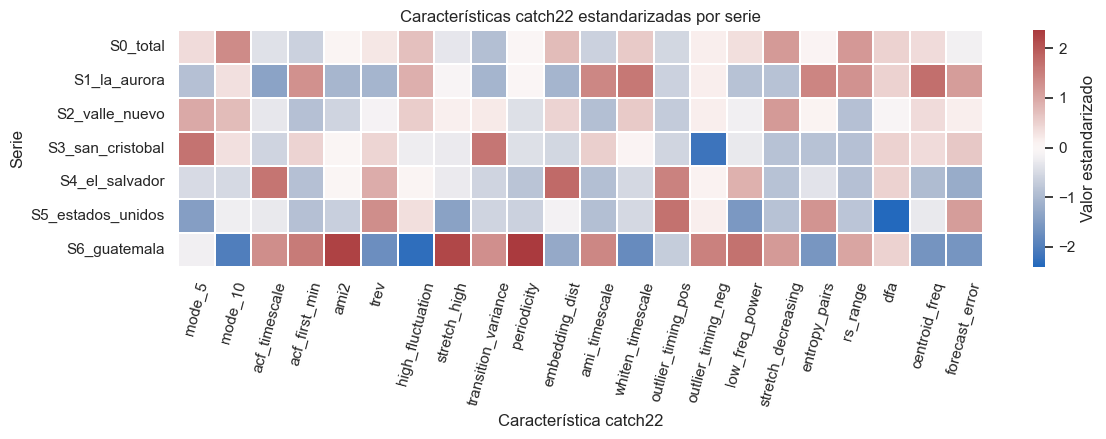

In [6]:
matriz_heatmap = matriz_estandarizada.rename(columns=NOMBRES_CORTOS)
figura, _ = graficar_heatmap(
    matriz_heatmap,
    DIR_IMG / "11_catch22_heatmap.png",
)
plt.show()

## 7. Análisis de Componentes Principales — PCA (2.5)

PCA resume las 22 columnas en ejes ortogonales. Se reportan tanto las
coordenadas de cada serie como las cargas, que indican qué características
contribuyen más a cada componente.

In [7]:
resultado_pca = calcular_pca(matriz_estandarizada, n_componentes=2)
coordenadas_pca = resultado_pca["coordenadas"]
cargas_pca = resultado_pca["cargas"]
varianza_pca = resultado_pca["varianza_explicada"]

coordenadas_pca.to_csv(DIR_RESULTADOS / "catch22_pca_coordenadas.csv")
cargas_pca.to_csv(DIR_RESULTADOS / "catch22_pca_cargas.csv")

print("Varianza explicada por componente:")
display((varianza_pca * 100).round(2).to_frame("varianza_%"))
print(f"Varianza acumulada PC1+PC2: {varianza_pca.sum() * 100:.2f}%")
coordenadas_pca.round(4)

Varianza explicada por componente:


,varianza_%
PC1,45.74
PC2,22.96


Varianza acumulada PC1+PC2: 68.70%


,PC1,PC2
serie,,
S0_total,-0.8184,-0.5173
S1_la_aurora,-1.7719,-4.0590
S2_valle_nuevo,-1.0811,-0.0495
S3_san_cristobal,-0.3329,-0.9786
S4_el_salvador,-0.1286,3.6642
S5_estados_unidos,-3.2625,2.0522
S6_guatemala,7.3954,-0.1120


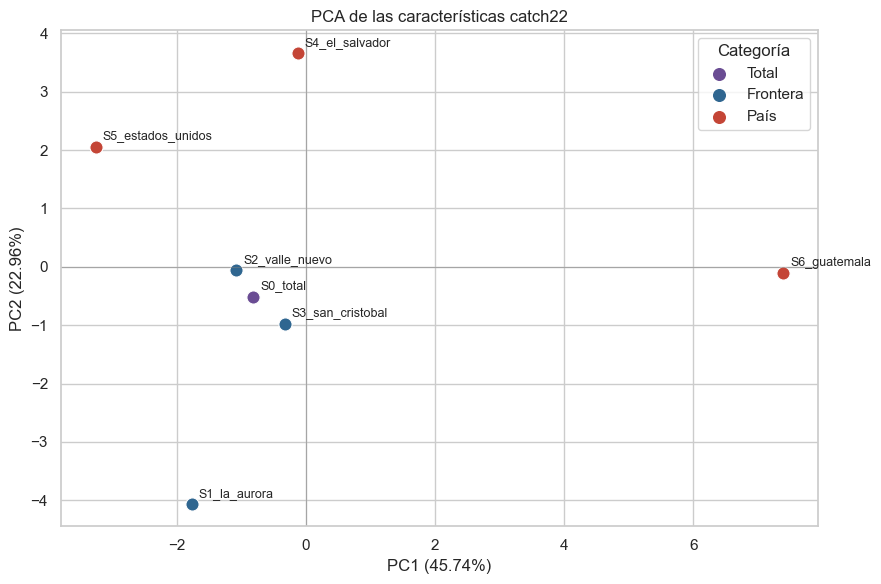

In [8]:
COLORES_CATEGORIA = {
    "Total": "#6a4c93",
    "Frontera": "#2f6690",
    "País": "#c44536",
}

figura, eje = plt.subplots(figsize=(9, 6))
for serie, fila in coordenadas_pca.iterrows():
    categoria = METADATOS_SERIES[serie][1]
    eje.scatter(
        fila["PC1"], fila["PC2"],
        color=COLORES_CATEGORIA[categoria], s=90,
        edgecolor="white", linewidth=0.8,
    )
    eje.annotate(serie, (fila["PC1"], fila["PC2"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=9)

for categoria, color in COLORES_CATEGORIA.items():
    eje.scatter([], [], color=color, label=categoria, s=70)
eje.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
eje.axvline(0, color="gray", linewidth=0.8, alpha=0.5)
eje.set_xlabel(f"PC1 ({varianza_pca['PC1'] * 100:.2f}%)")
eje.set_ylabel(f"PC2 ({varianza_pca['PC2'] * 100:.2f}%)")
eje.set_title("PCA de las características catch22")
eje.legend(title="Categoría")
figura.tight_layout()
figura.savefig(DIR_IMG / "12_catch22_pca.png", dpi=150, bbox_inches="tight")
plt.show()

### Características con mayor aporte al plano PCA (2.8)

Se usa la magnitud conjunta de las cargas en PC1 y PC2. Esta medida identifica
qué variables ayudan más a construir el plano mostrado, no equivale a una
importancia predictiva causal.

,nombre_corto,PC1,PC2,aporte_plano
caracteristica,,,,
SP_Summaries_welch_rect_centroid,centroid_freq,-0.2104,-0.3240,0.3863
CO_f1ecac,acf_timescale,0.1951,0.3295,0.3830
DN_OutlierInclude_p_001_mdrmd,outlier_timing_pos,-0.1184,0.3480,0.3676
CO_trev_1_num,trev,-0.2191,0.2856,0.3599
IN_AutoMutualInfoStats_40_gaussian_fmmi,ami_timescale,0.1733,-0.3150,0.3596
CO_FirstMin_ac,acf_first_min,0.1919,-0.2979,0.3544
FC_LocalSimple_mean1_tauresrat,whiten_timescale,-0.2177,-0.2761,0.3517
CO_Embed2_Dist_tau_d_expfit_meandiff,embedding_dist,-0.1139,0.3061,0.3266
FC_LocalSimple_mean3_stderr,forecast_error,-0.2492,-0.2002,0.3197


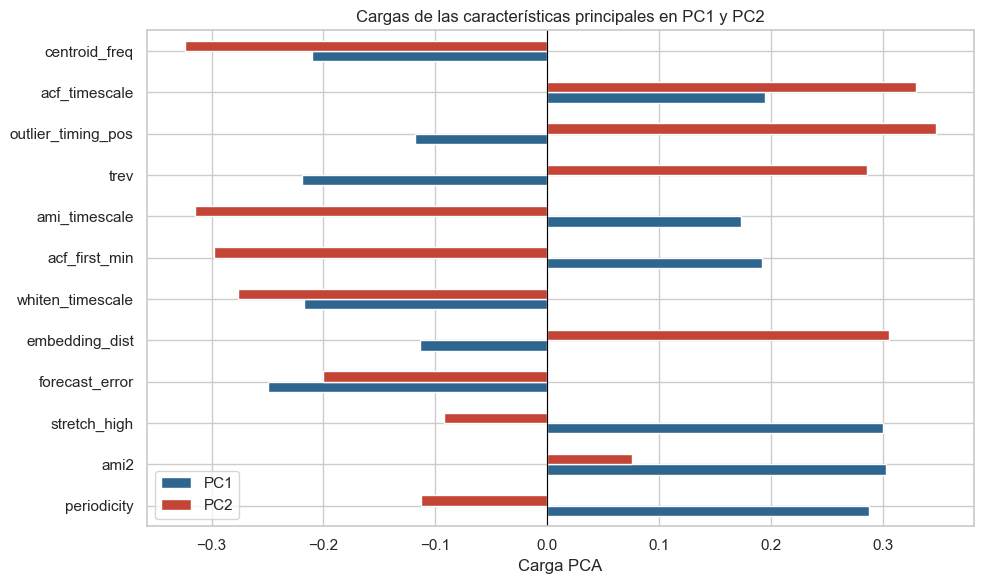

In [9]:
cargas_resumen = cargas_pca.copy()
cargas_resumen["aporte_plano"] = np.sqrt(
    cargas_resumen["PC1"] ** 2 + cargas_resumen["PC2"] ** 2
)
top_cargas = cargas_resumen.nlargest(12, "aporte_plano").copy()
top_cargas["nombre_corto"] = [NOMBRES_CORTOS[n] for n in top_cargas.index]

display(top_cargas[["nombre_corto", "PC1", "PC2", "aporte_plano"]].round(4))

grafica_cargas = top_cargas.set_index("nombre_corto")[["PC1", "PC2"]]
figura, eje = plt.subplots(figsize=(10, 6))
grafica_cargas.iloc[::-1].plot.barh(ax=eje, color=["#2f6690", "#c44536"])
eje.set_title("Cargas de las características principales en PC1 y PC2")
eje.set_xlabel("Carga PCA")
eje.set_ylabel("")
eje.axvline(0, color="black", linewidth=0.8)
figura.tight_layout()
figura.savefig(DIR_IMG / "13_catch22_cargas_pca.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Clustering K-means (2.5)

Se prueban `k=2..5` y se elige el mayor coeficiente silhouette. Un valor alto
indica grupos compactos y separados, un valor cercano a cero indica que la
separación es débil. Con solo siete series, el resultado debe tratarse como
exploratorio.

In [10]:
resultado_clusters = calcular_clustering(matriz_estandarizada, k=None)
clusters = resultado_clusters["etiquetas"]
puntajes_silhouette = resultado_clusters["silhouette_por_k"]

tabla_clusters = resumen_series[["nombre", "categoria"]].copy()
tabla_clusters["cluster"] = clusters
tabla_clusters.to_csv(DIR_RESULTADOS / "catch22_clusters.csv")

print(f"k seleccionado: {resultado_clusters['k']}")
print(f"Silhouette seleccionado: {resultado_clusters['silhouette']:.4f}")
display(puntajes_silhouette.round(4).to_frame())
tabla_clusters

k seleccionado: 2
Silhouette seleccionado: 0.3303


,silhouette
2,0.3303
3,0.1417
4,0.0847
5,0.1033


,nombre,categoria,cluster
serie,,,
S0_total,Total mensual,Total,0
S1_la_aurora,La Aurora,Frontera,0
S2_valle_nuevo,Valle Nuevo,Frontera,0
S3_san_cristobal,San Cristóbal,Frontera,0
S4_el_salvador,El Salvador,País,0
S5_estados_unidos,Estados Unidos,País,0
S6_guatemala,Guatemala,País,1


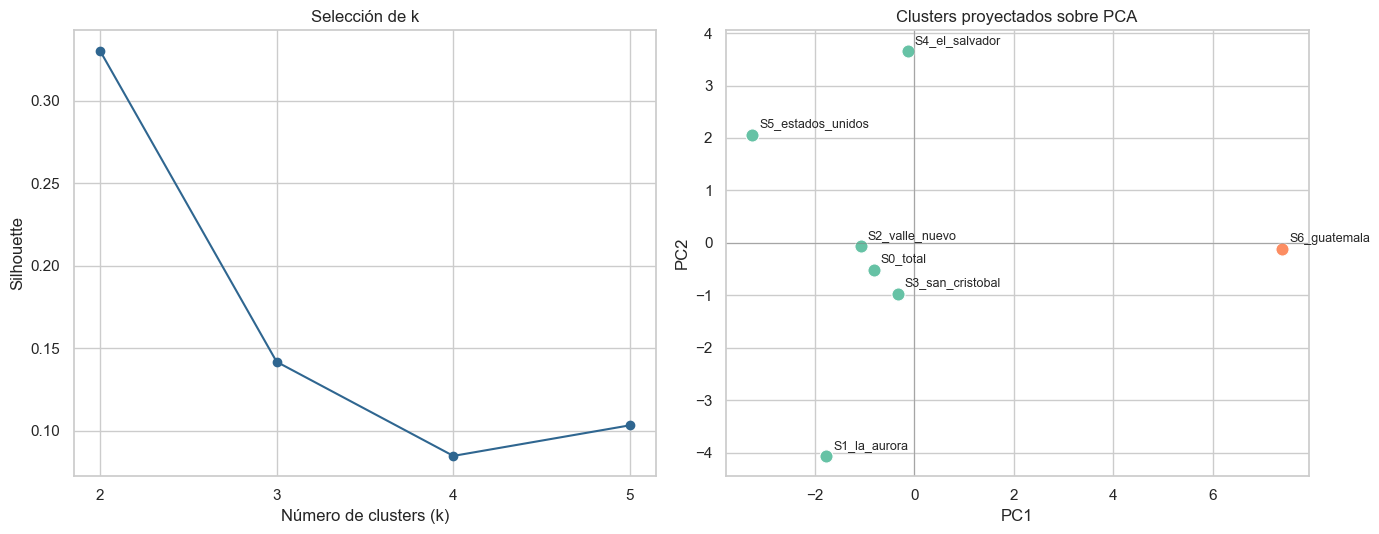

In [11]:
figura, ejes = plt.subplots(1, 2, figsize=(14, 5.5))

ejes[0].plot(
    puntajes_silhouette.index,
    puntajes_silhouette.values,
    marker="o", color="#2f6690",
)
ejes[0].set_xticks(puntajes_silhouette.index)
ejes[0].set_xlabel("Número de clusters (k)")
ejes[0].set_ylabel("Silhouette")
ejes[0].set_title("Selección de k")

paleta_clusters = sns.color_palette("Set2", n_colors=resultado_clusters["k"])
for serie, fila in coordenadas_pca.iterrows():
    cluster = int(clusters.loc[serie])
    ejes[1].scatter(fila["PC1"], fila["PC2"], s=90,
                    color=paleta_clusters[cluster],
                    edgecolor="white", linewidth=0.8)
    ejes[1].annotate(serie, (fila["PC1"], fila["PC2"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=9)
ejes[1].axhline(0, color="gray", linewidth=0.8, alpha=0.5)
ejes[1].axvline(0, color="gray", linewidth=0.8, alpha=0.5)
ejes[1].set_xlabel("PC1")
ejes[1].set_ylabel("PC2")
ejes[1].set_title("Clusters proyectados sobre PCA")

figura.tight_layout()
figura.savefig(DIR_IMG / "14_catch22_clustering.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Correlaciones entre características (2.5)

La matriz permite detectar características que varían de forma parecida entre
las siete series. Como solo hay siete observaciones, correlaciones altas pueden
ser inestables y no deben interpretarse como relaciones universales ni
causales.

In [12]:
correlaciones = matriz_correlacion(matriz_estandarizada)
correlaciones.to_csv(DIR_RESULTADOS / "catch22_correlaciones.csv")

pares_correlacion = []
for indice, caracteristica_a in enumerate(correlaciones.columns):
    for caracteristica_b in correlaciones.columns[indice + 1:]:
        valor = correlaciones.loc[caracteristica_a, caracteristica_b]
        pares_correlacion.append({
            "caracteristica_a": NOMBRES_CORTOS[caracteristica_a],
            "caracteristica_b": NOMBRES_CORTOS[caracteristica_b],
            "correlacion": valor,
            "correlacion_absoluta": abs(valor),
        })
top_correlaciones = (
    pd.DataFrame(pares_correlacion)
    .sort_values("correlacion_absoluta", ascending=False)
    .head(10)
)
top_correlaciones[["caracteristica_a", "caracteristica_b", "correlacion"]].round(4)

,caracteristica_a,caracteristica_b,correlacion
67,acf_first_min,ami_timescale,0.9970
193,whiten_timescale,centroid_freq,0.9676
215,low_freq_power,forecast_error,-0.9639
79,ami2,high_fluctuation,-0.9468
58,acf_timescale,centroid_freq,-0.9239
127,stretch_high,periodicity,0.9036
59,acf_timescale,forecast_error,-0.9014
25,mode_10,high_fluctuation,0.8702
116,high_fluctuation,whiten_timescale,0.8607
82,ami2,periodicity,0.8588


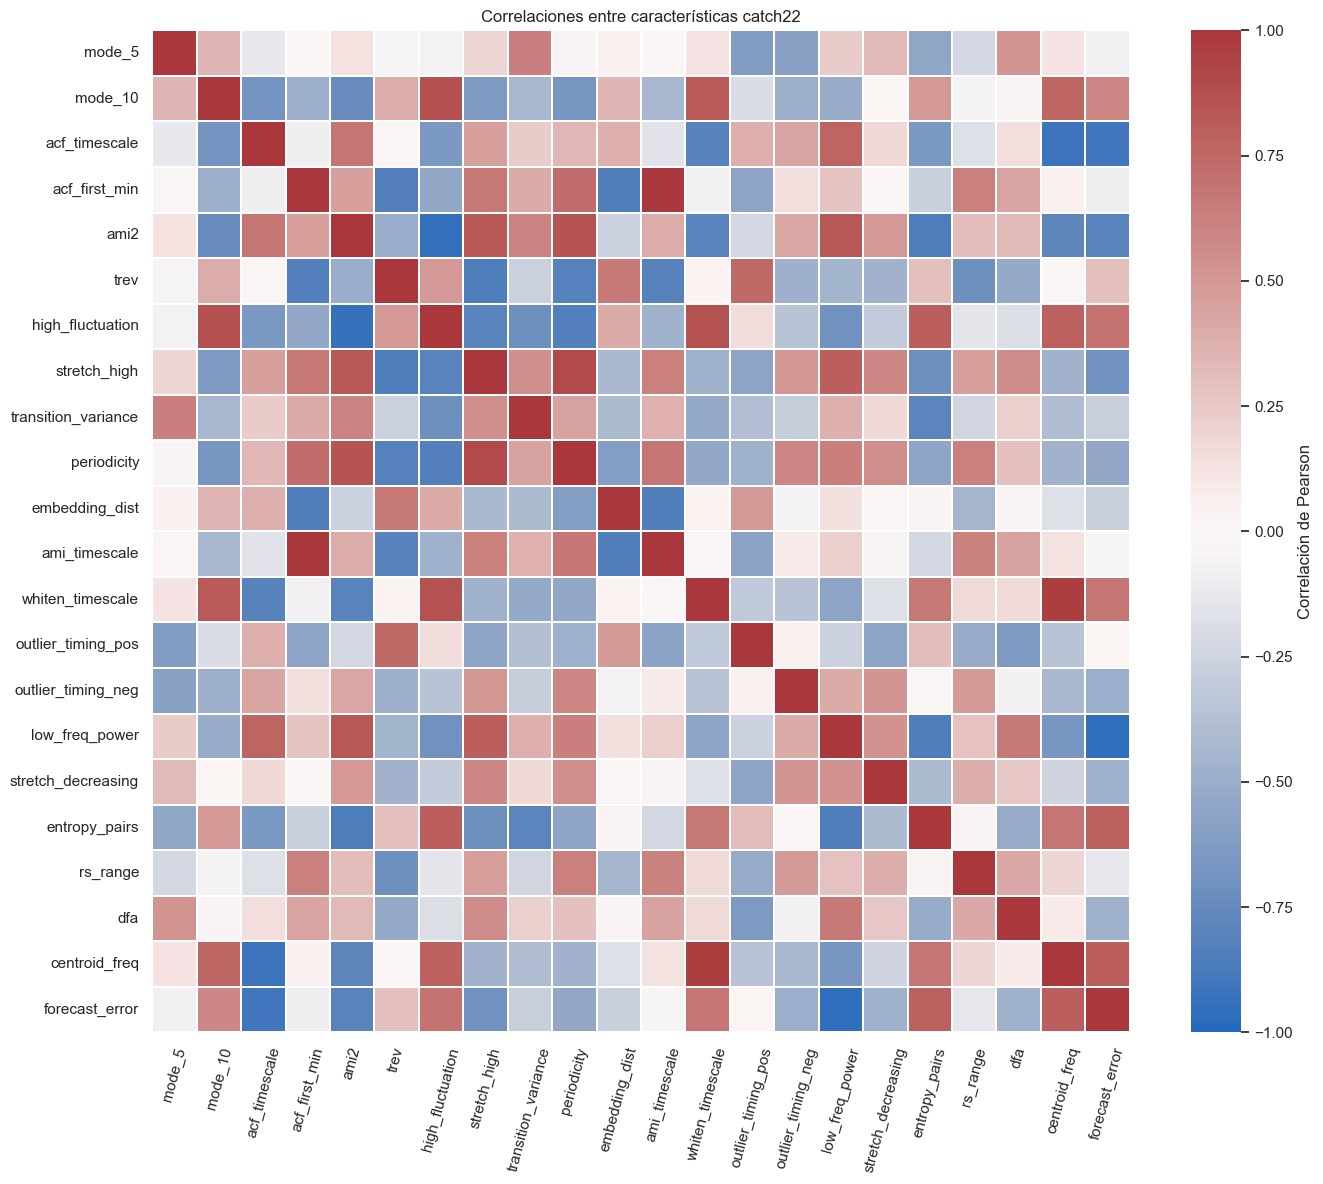

In [13]:
correlaciones_cortas = correlaciones.rename(
    index=NOMBRES_CORTOS,
    columns=NOMBRES_CORTOS,
)
figura, eje = plt.subplots(figsize=(14, 12))
sns.heatmap(
    correlaciones_cortas,
    cmap="vlag", center=0, vmin=-1, vmax=1,
    linewidths=0.15,
    cbar_kws={"label": "Correlación de Pearson"},
    ax=eje,
)
eje.set_title("Correlaciones entre características catch22")
eje.tick_params(axis="x", labelrotation=75)
eje.tick_params(axis="y", labelrotation=0)
figura.tight_layout()
figura.savefig(DIR_IMG / "15_catch22_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Distancias entre series (2.5 y 2.7)

Se calcula distancia euclidiana sobre las 22 columnas estandarizadas. Una
distancia menor indica que dos series comparten una firma dinámica catch22 más
parecida, no implica que tengan el mismo volumen de viajeros.

In [14]:
distancias = matriz_distancias(matriz_estandarizada, metrica="euclidean")
distancias.to_csv(DIR_RESULTADOS / "catch22_distancias.csv")

pares_distancia = pd.DataFrame([
    {"serie_a": a, "serie_b": b, "distancia": distancias.loc[a, b]}
    for a, b in combinations(distancias.index, 2)
]).sort_values("distancia")

print("Cinco pares más cercanos:")
display(pares_distancia.head(5).round(4))
print("Cinco pares más distantes:")
display(pares_distancia.tail(5).sort_values("distancia", ascending=False).round(4))

Cinco pares más cercanos:


,serie_a,serie_b,distancia
1,S0_total,S2_valle_nuevo,2.8616
11,S2_valle_nuevo,S3_san_cristobal,4.5268
12,S2_valle_nuevo,S4_el_salvador,5.2390
3,S0_total,S4_el_salvador,5.3067
0,S0_total,S1_la_aurora,5.4390


Cinco pares más distantes:


,serie_a,serie_b,distancia
20,S5_estados_unidos,S6_guatemala,11.0519
10,S1_la_aurora,S6_guatemala,10.1415
14,S2_valle_nuevo,S6_guatemala,9.0809
17,S3_san_cristobal,S6_guatemala,8.9884
5,S0_total,S6_guatemala,8.9313


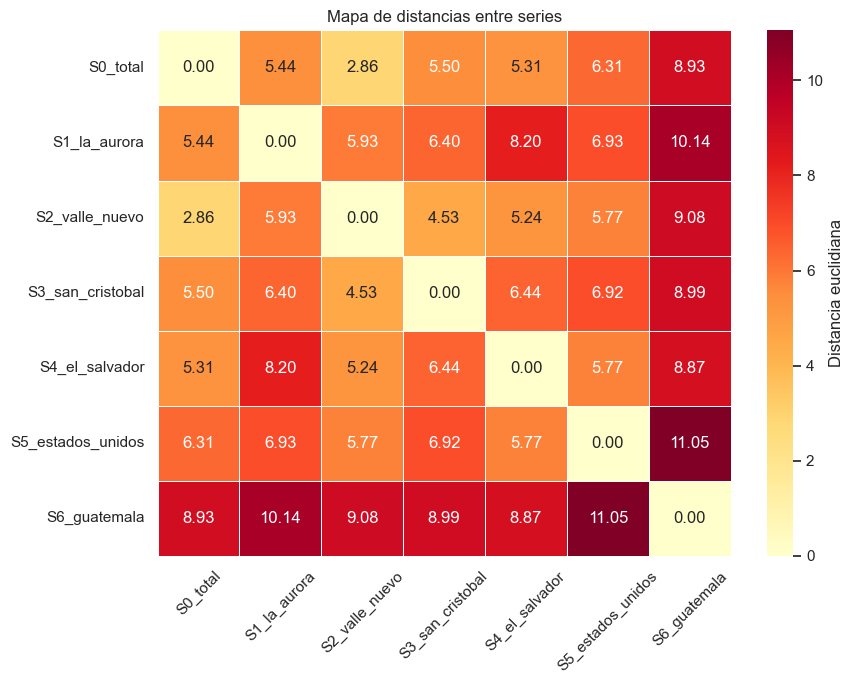

In [15]:
figura, eje = plt.subplots(figsize=(9, 7))
sns.heatmap(
    distancias,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Distancia euclidiana"},
    ax=eje,
)
eje.set_title("Mapa de distancias entre series")
eje.set_xlabel("")
eje.set_ylabel("")
eje.tick_params(axis="x", labelrotation=45)
eje.tick_params(axis="y", labelrotation=0)
figura.tight_layout()
figura.savefig(DIR_IMG / "16_catch22_distancias.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Análisis e interpretación (2.6–2.11)

### Series más similares

El par más cercano es **S0 Total–S2 Valle Nuevo**, con distancia **2.86**. Le
siguen **S2–S3** (4.53) y **S2–S4** (5.24). PCA también coloca a S0, S2 y S3 en
una región relativamente próxima. La similitud S0–S2 no significa que manejen
el mismo volumen: catch22 elimina el nivel y señala que sus patrones relativos
de dependencia, fluctuación y estructura temporal son parecidos.

### Características que más diferencian

PC1 explica **45.74%** y PC2 **22.96%**, juntos conservan **68.70%** de la
variación. En el plano de dos componentes destacan:

- `centroid_freq` y `acf_timescale`: distribución de potencia y escala de la
  autocorrelación,
- `outlier_timing_pos` y `trev`: ubicación de extremos positivos y asimetría de
  los cambios,
- `ami_timescale` y `acf_first_min`: dependencia temporal lineal y no lineal,
- `whiten_timescale`, `forecast_error`, `stretch_high`, `ami2` y `periodicity`.

Estas cargas indican qué construye la separación observada, no prueban que una
característica cause el comportamiento de una serie.

### Grupos naturales y categorías

El mejor resultado fue **k=2**, con silhouette **0.3303**. Es una separación
moderada, no evidencia de dos grupos compactos: un cluster contiene S0–S5 y el
otro contiene únicamente **S6 Guatemala**. Las categorías no se recuperan de
forma limpia. Aunque S2–S3 son fronteras cercanas y S4–S5 forman un par
razonablemente próximo, S2–S4 —un cruce frontera–país— resulta más cercano que
S4–S5. Por tanto, compartir una etiqueta de negocio no garantiza compartir la
misma dinámica temporal.

### Serie más atípica

**S6 Guatemala** es el caso más atípico: es el único miembro de su cluster,
tiene la mayor distancia promedio al resto (**9.51**) y alcanza la máxima
distancia con S5 Estados Unidos (**11.05**). Entre sus desviaciones más fuertes
aparecen periodicidad, información mutua, rachas sobre la media y una proporción
muy baja de fluctuaciones sucesivas altas.

La explicación principal es conocida por el análisis de la fuente: S6 queda en
cero durante 42 meses desde enero de 2023 porque Guatemala deja de reportarse
como país individual. catch22 detecta con claridad la ruptura dinámica, pero no
puede determinar por sí solo que la causa sea un cambio de registro.

## 12. Comparación con el EDA tradicional (2.12)

| Serie | Fuerza de tendencia | Fuerza estacional | Observación previa relevante |
|---|---:|---:|---|
| S0 Total | 0.821 | 0.467 | Tendencia dominante y recuperación pospandemia |
| S1 La Aurora | 0.811 | 0.559 | Mayor estacionalidad entre fronteras |
| S2 Valle Nuevo | 0.766 | 0.311 | Menor estacionalidad y alta volatilidad mensual |
| S3 San Cristóbal | 0.707 | 0.399 | Mayor crecimiento relativo y alta dispersión |
| S4 El Salvador | 0.783 | 0.402 | Mayor crecimiento prepandemia entre países |
| S5 Estados Unidos | 0.709 | 0.704 | Mayor estacionalidad entre países |
| S6 Guatemala | 0.840 | 0.506 | 42 ceros desde 2023 por cambio de reporte |

Los resultados son parcialmente consistentes con el EDA:

- S0 y S2 son principalmente series de tendencia con estacionalidad más baja
  que S1 o S5, lo que ayuda a explicar su proximidad dinámica.
- S1 y S5, las series con estacionalidad más marcada dentro de sus categorías,
  ocupan posiciones diferenciadas en PCA por su estructura espectral y de
  autocorrelación, aunque no forman un cluster conjunto.
- El aislamiento de S6 coincide con el quiebre de registro observado desde
  2023 y es mucho más fuerte que la separación debida únicamente a tendencia o
  estacionalidad.
- La pandemia afecta las siete series, pero catch22 resume su efecto junto con
  todo el período. No identifica fechas ni causas, esas conclusiones siguen
  requiriendo las gráficas, el conocimiento de la fuente y el análisis ACF.

El EDA explica **cuándo y por qué** ocurrieron los cambios, catch22 cuantifica
**qué tan parecida es la dinámica completa** entre series.

## 13. Descubrimientos adicionales de catch22 (2.13)

1. **La serie total se parece más a Valle Nuevo que a La Aurora.** Por volumen,
   La Aurora parecía el componente más cercano al total, al eliminar escala y
   comparar 22 propiedades dinámicas, S0–S2 resulta el par más próximo.

2. **Las categorías administrativas no forman fronteras dinámicas claras.** El
   par cruzado S2–S4 es más cercano que el par de países S4–S5. La vía o el país
   describen el significado del dato, pero no determinan por sí solos su firma
   temporal.

3. **El quiebre de S6 domina múltiples dimensiones, no solamente su nivel.** La
   serie no solo presenta 42 ceros: también queda aislada por periodicidad,
   dependencia no lineal, rachas y patrón de cambios sucesivos. La matriz de
   distancias convierte esa impresión visual en una separación cuantificable.

4. **La separación principal depende más de estructura temporal que de
   magnitud.** Las características con mayor carga se relacionan con ACF,
   información mutua, espectro, eventos extremos y reversibilidad temporal. Esto
   complementa al EDA, que estaba concentrado en nivel, tendencia, volatilidad y
   estacionalidad.

## 14. Limitaciones y cierre

- Solo existen siete series. PCA es descriptivo, el silhouette de 0.3303 es
  moderado y las correlaciones entre 22 características se estiman con apenas
  siete observaciones.
- catch22 es deliberadamente insensible a media y desviación estándar, dos
  series con volúmenes muy distintos pueden resultar cercanas.
- Las características describen el período completo y mezclan la operación
  normal, la pandemia, la recuperación y los cambios metodológicos de 2023.
- Un agrupamiento no explica causalidad. Las interpretaciones requieren volver
  al codebook y al EDA del Laboratorio 1.

Con estas cautelas, catch22 aporta una representación común y reproducible que
confirma a S6 como caso atípico, muestra similitudes que cruzan las categorías y
prioriza propiedades temporales que no eran fáciles de comparar visualmente.
El siguiente paso es construir el experimento LSTM+catch22 sin utilizar
información futura.

## 15. Modelo LSTM con características catch22 (2.14)

Para evaluar si la caracterización temporal aporta información al pronóstico,
se vuelve a modelar **S0_total** con la configuración del mejor LSTM base:
`lookback=24`, 64 unidades, dos capas y `dropout=0.2`. La única diferencia
experimental es que cada paso de la entrada contiene 23 variables: el valor de
viajeros escalado y la firma estandarizada de 22 características catch22 de S0.

Para evitar fuga de información, las firmas se recalculan usando exclusivamente
los primeros 147 meses de las siete series y se estandarizan entre esas siete
filas de entrenamiento. El vector de S0 se mantiene constante dentro de cada
ventana, mientras el valor mensual cambia. Ninguno de los 63 valores reales del
período de prueba participa en la construcción de variables ni escaladores.

In [16]:
from ast import literal_eval

from IPython.display import Markdown, display

from evaluacion_modelos import (
    calcular_metricas,
    graficar_real_pronostico,
    tabla_comparativa,
)
from modelos_lstm import entrenar_lstm_catch22
from utils_ts import partir_train_test

SEED = 42
series_train = {
    nombre: partir_train_test(serie)[0]
    for nombre, serie in series.items()
}
train_s0 = series_train["S0_total"]
_, test_s0 = partir_train_test(series["S0_total"])

matriz_catch22_train = construir_matriz_catch22(series_train)
matriz_catch22_train_estandarizada = estandarizar_matriz(matriz_catch22_train)
catch22_s0 = matriz_catch22_train_estandarizada.loc["S0_total"].to_numpy()

matriz_catch22_train.to_csv(DIR_RESULTADOS / "catch22_matriz_train.csv")
matriz_catch22_train_estandarizada.to_csv(
    DIR_RESULTADOS / "catch22_matriz_train_estandarizada.csv"
)

tabla_base = pd.read_csv(DIR_RESULTADOS / "lstm_s0.csv")
mascara_mejor = tabla_base["mejor_modelo"].astype(str).str.lower().eq("true")
mejor_base = tabla_base.loc[mascara_mejor].iloc[0]
parametros_base = literal_eval(mejor_base["parametros"])

PARAMETROS_CATCH22 = {
    "lookback": int(parametros_base["lookback"]),
    "unidades": int(parametros_base["unidades"]),
    "capas": int(parametros_base["capas"]),
    "dropout": float(parametros_base["dropout"]),
    "epochs": int(parametros_base["epochs"]),
    "batch_size": int(parametros_base["batch_size"]),
}

assert matriz_catch22_train.shape == (7, 22)
assert len(catch22_s0) == 22
print(f"Entrenamiento: {len(train_s0)} meses; prueba: {len(test_s0)} meses")
print("Parámetros:", PARAMETROS_CATCH22)
print("Forma esperada por muestra: (24, 23)")

Entrenamiento: 147 meses; prueba: 63 meses
Parámetros: {'lookback': 24, 'unidades': 64, 'capas': 2, 'dropout': 0.2, 'epochs': 100, 'batch_size': 16}
Forma esperada por muestra: (24, 23)


In [17]:
resultado_lstm_catch22 = entrenar_lstm_catch22(
    train=train_s0,
    test=test_s0,
    catch22_features=catch22_s0,
    seed=SEED,
    **PARAMETROS_CATCH22,
)
pred_catch22 = resultado_lstm_catch22["y_pred"]

assert pred_catch22.index.equals(test_s0.index)
assert len(pred_catch22) == 63
assert np.isfinite(pred_catch22.to_numpy()).all()
assert resultado_lstm_catch22["forma_entrenamiento"] == (123, 24, 23)

print("Forma del entrenamiento:", resultado_lstm_catch22["forma_entrenamiento"])
print(
    "Épocas ejecutadas:",
    len(resultado_lstm_catch22["historial"].history["loss"]),
)

Forma del entrenamiento: (123, 24, 23)
Épocas ejecutadas: 57


In [18]:
metricas_catch22 = calcular_metricas(test_s0, pred_catch22)
fila_catch22 = {
    "serie": "S0_total",
    "modelo": "LSTM-catch22-contexto-w24",
    "parametros": PARAMETROS_CATCH22,
    "transformacion": "MinMax objetivo + catch22 estandarizado en train",
    "AIC": np.nan,
    "BIC": np.nan,
    **metricas_catch22,
    "Ljung_Box_p": np.nan,
    "Jarque_Bera_p": np.nan,
    "mejor_modelo": False,
}

comparacion_lstm_catch22 = tabla_comparativa([
    mejor_base.to_dict(),
    fila_catch22,
])
comparacion_lstm_catch22.to_csv(
    DIR_RESULTADOS / "lstm_catch22_s0.csv",
    index=False,
)

pronostico_lstm_catch22 = pd.DataFrame({
    "fecha": test_s0.index,
    "y_real": test_s0.to_numpy(),
    "y_pred": pred_catch22.to_numpy(),
})
pronostico_lstm_catch22.to_csv(
    DIR_RESULTADOS / "pronostico_lstm_catch22_s0.csv",
    index=False,
)

comparacion_lstm_catch22[[
    "modelo", "MAE", "RMSE", "MAPE", "mejor_modelo"
]].round(2)

,modelo,MAE,RMSE,MAPE,mejor_modelo
0,LSTM-2capas-w24,39076.57,50988.18,23.44,True
1,LSTM-catch22-contexto-w24,55256.39,67734.70,29.16,False


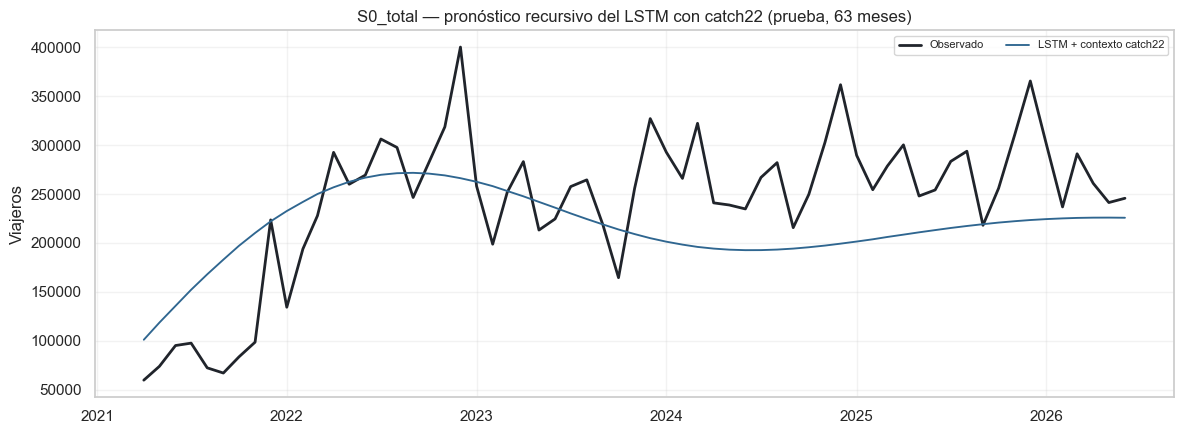

In [19]:
figura, _ = graficar_real_pronostico(
    y_real=test_s0,
    pronosticos={"LSTM + contexto catch22": pred_catch22},
    titulo=(
        "S0_total — pronóstico recursivo del LSTM con catch22 "
        "(prueba, 63 meses)"
    ),
    ruta_salida=DIR_IMG / "17_lstm_catch22_s0.png",
)
plt.show()

In [20]:
rmse_base = float(mejor_base["RMSE"])
rmse_catch22 = float(metricas_catch22["RMSE"])
mae_base = float(mejor_base["MAE"])
mae_catch22 = float(metricas_catch22["MAE"])
cambio_rmse = 100 * (rmse_catch22 - rmse_base) / rmse_base
cambio_mae = 100 * (mae_catch22 - mae_base) / mae_base

if rmse_catch22 < rmse_base:
    veredicto = (
        "El modelo con catch22 **mejoró** el pronóstico: su RMSE fue "
        f"{rmse_catch22:,.2f}, frente a {rmse_base:,.2f} del LSTM base "
        f"({abs(cambio_rmse):.2f}% menos)."
    )
else:
    veredicto = (
        "El modelo con catch22 **no superó** al LSTM base: su RMSE fue "
        f"{rmse_catch22:,.2f}, frente a {rmse_base:,.2f} "
        f"({cambio_rmse:.2f}% más)."
    )

display(Markdown(f"""### Discusión del resultado

{veredicto} El MAE cambió de {mae_base:,.2f} a {mae_catch22:,.2f}
({cambio_mae:+.2f}%). La comparación usa el mismo horizonte de 63 meses, el
mismo corte temporal y la misma arquitectura; por tanto, la diferencia se
concentra en la representación de entrada, aunque el entrenamiento neuronal
conserva variación estocástica.

En S0, las variables catch22 funcionan como un contexto global constante para
todas las ventanas. Esto satisface la incorporación de las 22 características,
pero no agrega variación entre muestras de una misma serie y aumenta la
dimensionalidad de 1 a 23 entradas por paso. El resultado muestra que la gran
utilidad descriptiva de catch22 para comparar series no implica necesariamente
una mejora predictiva cuando se entrena una LSTM para una sola serie."""))

### Discusión del resultado

El modelo con catch22 **no superó** al LSTM base: su RMSE fue 67,734.70, frente a 50,988.18 (32.84% más). El MAE cambió de 39,076.57 a 55,256.39
(+41.41%). La comparación usa el mismo horizonte de 63 meses, el
mismo corte temporal y la misma arquitectura; por tanto, la diferencia se
concentra en la representación de entrada, aunque el entrenamiento neuronal
conserva variación estocástica.

En S0, las variables catch22 funcionan como un contexto global constante para
todas las ventanas. Esto satisface la incorporación de las 22 características,
pero no agrega variación entre muestras de una misma serie y aumenta la
dimensionalidad de 1 a 23 entradas por paso. El resultado muestra que la gran
utilidad descriptiva de catch22 para comparar series no implica necesariamente
una mejora predictiva cuando se entrena una LSTM para una sola serie.